In [28]:
%load_ext autoreload
%autoreload 2

# Get parent directory and add to sys.path
import sys, os
parent_dir = os.path.dirname(os.getcwd())
sys.path.append(parent_dir)

# Require ipympl
%matplotlib widget 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [29]:
import time
from LandMPC.MPCLandControl import MPCLandControl
from src.rocket import Rocket, perturb_rocket
from src.pos_rocket_vis import *

rocket_obj_path = os.path.join(parent_dir, "Cartoon_rocket.obj")
rocket_params_path = os.path.join(parent_dir,"rocket.yaml")

# Rocket setup
Ts  = 1/20
rocket = Rocket(Ts=Ts, model_params_filepath=rocket_params_path)
rocket.mass = 1.7 # Do not change!!!

# Visualization setup
vis = RocketVis(rocket, rocket_obj_path)
vis.anim_rate = 1

In [30]:
sim_time = 10.0 # simulation length in seconds
x0 = np.array([
    0, 0, 0,				# omega
    0, 0, np.deg2rad(30), 	# varphi
    0, 0, 0, 				# v
    3, 2, 10				# p
])
x_ref = np.array([
    0, 0, 0,	# omega
    0, 0, 0,	# varphi
    0, 0, 0,	# v
    1, 0, 3		# p
])
xs, us = rocket.trim(x_ref)
print("Linearization around a steady state:")
print("x_ref = ", x_ref)
print("xs = ", xs)
print("us = ", us)
A, B = rocket.linearize(xs, us)

# MPC parameters
H = 10.0
# Merge four linear mpc
mpc = MPCLandControl().new_controller(rocket, Ts, H, x_ref=x_ref)

Linearization around a steady state:
x_ref =  [0 0 0 0 0 0 0 0 0 1 0 3]
xs =  [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 3.]
us =  [ 0.          0.         56.66666667  0.        ]


In [31]:
t_cl, x_cl, u_cl, t_ol, x_ol, u_ol = rocket.simulate_land(mpc, sim_time, H, x0)

Simulating time 0.00

 State alpha violation: 0.20 > 0.17, 
 State alpha violation: 0.25 > 0.17, 
 State alpha violation: 0.28 > 0.17, 
 State alpha violation: 0.29 > 0.17, 
 State beta violation: -0.19 < -0.17, 
 State alpha violation: 0.29 > 0.17, 
 State beta violation: -0.20 < -0.17, 
 State alpha violation: 0.28 > 0.17, 
 State beta violation: -0.22 < -0.17, 
 State alpha violation: 0.26 > 0.17, 
 State beta violation: -0.22 < -0.17, 
 State alpha violation: 0.24 > 0.17, 
 State beta violation: -0.22 < -0.17, 
 State alpha violation: 0.22 > 0.17, 
 State beta violation: -0.22 < -0.17, 
 State alpha violation: 0.19 > 0.17, 
 State beta violation: -0.21 < -0.17, 
 State alpha violation: 0.18 > 0.17, 
 State beta violation: -0.20 < -0.17, 
 State beta violation: -0.19 < -0.17, 
 State beta violation: -0.18 < -0.17, Simulating time 1.00
Simulating time 2.00
Simulating time 3.00
Simulating time 4.00
Simulating time 5.00
Simulating time 6.00
Simulating time 7.00
Simulating time 8.00
Sim

In [32]:
vis.animate(t_cl[:-1], x_cl[:,:-1], u_cl, T_ol=t_ol[...,:-1], X_ol=x_ol, U_ol=u_ol)

AppLayout(children=(HBox(children=(Play(value=0, description='Press play', max=199, step=2), IntSlider(value=0…

{'fig': <Figure size 640x480 with 16 Axes>,
 'axes': [<Axes: ylabel='inputs'>,
  <Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: title={'center': 'Subsystem Y'}>,
  <Axes: title={'center': 'Subsystem X'}, ylabel='$\\omega_{\\phi\\theta\\psi}$ (deg/s)'>,
  <Axes: title={'center': 'Subsystem Z'}>,
  <Axes: >,
  <Axes: ylabel='$\\phi\\theta\\psi$ (deg)'>,
  <Axes: title={'center': 'Subsystem Roll'}>,
  <Axes: ylabel='$v_{\\text{ENU}}$ (m/s)'>,
  <Axes: >,
  <Axes: >,
  <Axes: ylabel='$\\text{pos}_{\\text{ENU}}$ (m)'>,
  <Axes: >,
  <Axes: >],
 'plotter': <pyvista.plotting.plotter.Plotter at 0x18478f2ee90>,
 'scene_objects': {'rocket_actor': Actor (0x18478f92bc0)
    Center:                     (3.060356440456486, 1.7874210169066358, 10.5884845)
    Pickable:                   True
    Position:                   (0.0, 0.0, 0.0)
    Scale:                      (1.0, 1.0, 1.0)
    Visible:                    True
    X Bounds                    1.998E+00, 4.122E+00
    Y Bounds                  

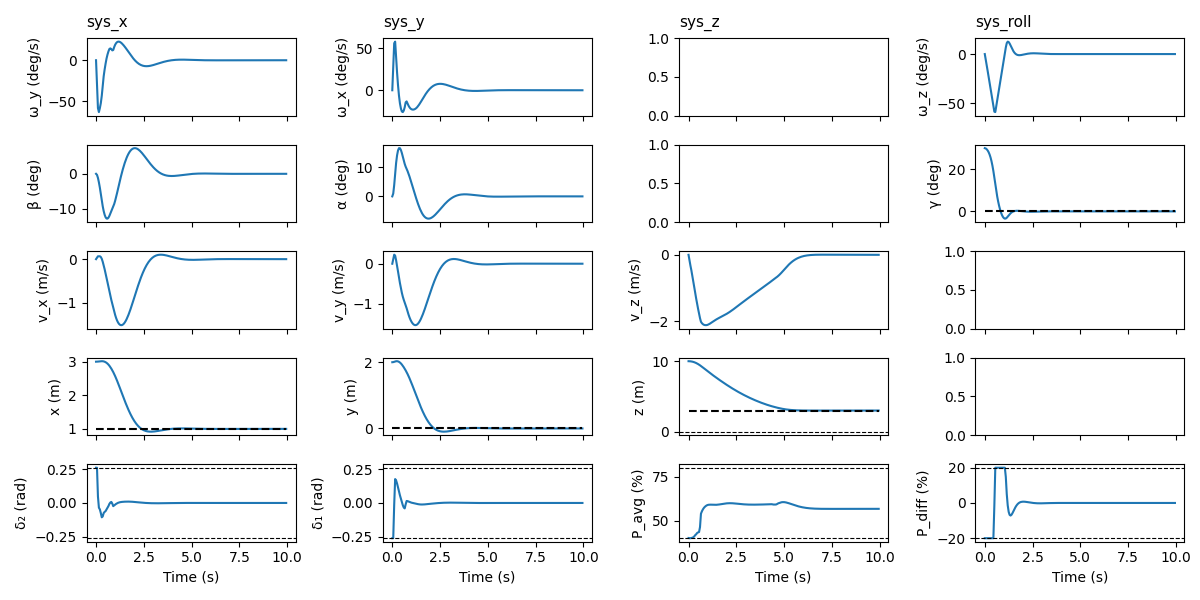

In [33]:
plot_static_states_inputs(t_cl[:-1], x_cl[:,:-1], u_cl, xs)
plt.savefig('merged-controllers-closed-loop')